In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/raw/Customer-Churn-Records.csv')
print(df.shape)
print(df.dtypes)
df.head()

(10000, 18)
RowNumber               int64
CustomerId              int64
Surname                object
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
# Clean column names first — removes spaces, lowercases everything
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['rownumber', 'customerid', 'surname', 'creditscore', 'geography', 'gender', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard', 'isactivemember', 'estimatedsalary', 'exited', 'complain', 'satisfaction_score', 'card_type', 'point_earned']


In [5]:
print(df.isnull().sum())

rownumber             0
customerid            0
surname               0
creditscore           0
geography             0
gender                0
age                   0
tenure                0
balance               0
numofproducts         0
hascrcard             0
isactivemember        0
estimatedsalary       0
exited                0
complain              0
satisfaction_score    0
card_type             0
point_earned          0
dtype: int64


In [6]:
df = df.drop(columns=['rownumber', 'customerid', 'surname'])
print(df.shape)

(10000, 15)


In [7]:
# Save cleaned data
df.to_csv('../data/processed/churn_clean.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!


In [8]:
# ---- KPI 1: Overall CX Health Snapshot ----
kpi_summary = {
    'Total Customers': len(df),
    'Churn Rate (%)': round(df['exited'].mean() * 100, 2),
    'Complaint Rate (%)': round(df['complain'].mean() * 100, 2),
    'Avg Satisfaction Score': round(df['satisfaction_score'].mean(), 2),
    'Active Member Rate (%)': round(df['isactivemember'].mean() * 100, 2),
    'Avg Tenure (Years)': round(df['tenure'].mean(), 1),
    'Avg Credit Score': round(df['creditscore'].mean(), 0)
}

for k, v in kpi_summary.items():
    print(f"{k:<30} {v}")

Total Customers                10000
Churn Rate (%)                 20.38
Complaint Rate (%)             20.44
Avg Satisfaction Score         3.01
Active Member Rate (%)         51.51
Avg Tenure (Years)             5.0
Avg Credit Score               651.0


In [9]:
# ---- KPI 2: Regional CX Performance ----
regional = df.groupby('geography').agg(
    total_customers=('exited', 'count'),
    churn_rate=('exited', 'mean'),
    complaint_rate=('complain', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_balance=('balance', 'mean'),
    active_rate=('isactivemember', 'mean')
).round(3)

regional['churn_rate_pct'] = (regional['churn_rate'] * 100).round(1)
regional['complaint_rate_pct'] = (regional['complaint_rate'] * 100).round(1)

print(regional[['total_customers', 'churn_rate_pct', 'complaint_rate_pct', 'avg_satisfaction', 'active_rate']])

           total_customers  churn_rate_pct  complaint_rate_pct  \
geography                                                        
France                5014            16.2                16.2   
Germany               2509            32.4                32.6   
Spain                 2477            16.7                16.7   

           avg_satisfaction  active_rate  
geography                                 
France                3.018        0.517  
Germany               3.006        0.497  
Spain                 3.014        0.530  


In [10]:
# ---- KPI 3: Complaint Impact on Churn ----
complaint_impact = df.groupby('complain').agg(
    total=('exited', 'count'),
    churn_rate=('exited', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_tenure=('tenure', 'mean')
).round(3)

complaint_impact.index = ['No Complaint', 'Complained']
complaint_impact['churn_rate_pct'] = (complaint_impact['churn_rate'] * 100).round(1)
print(complaint_impact[['total', 'churn_rate_pct', 'avg_satisfaction', 'avg_tenure']])

              total  churn_rate_pct  avg_satisfaction  avg_tenure
No Complaint   7956             0.1             3.017       5.032
Complained     2044            99.5             3.000       4.938


In [11]:
# ---- KPI 4: Satisfaction Score vs Churn (NPS-style) ----
sat_churn = df.groupby('satisfaction_score').agg(
    total=('exited', 'count'),
    churn_rate=('exited', 'mean'),
    complaint_rate=('complain', 'mean')
).round(3)

sat_churn['churn_rate_pct'] = (sat_churn['churn_rate'] * 100).round(1)
print(sat_churn[['total', 'churn_rate_pct', 'complaint_rate']])

                    total  churn_rate_pct  complaint_rate
satisfaction_score                                       
1                    1932            20.0           0.200
2                    2014            21.8           0.217
3                    2042            19.6           0.199
4                    2008            20.6           0.206
5                    2004            19.8           0.200


In [12]:
# ---- KPI 5: Card Tier Performance ----
card_kpis = df.groupby('card_type').agg(
    total=('exited', 'count'),
    churn_rate=('exited', 'mean'),
    complaint_rate=('complain', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_points=('point_earned', 'mean'),
    avg_balance=('balance', 'mean')
).round(3)

card_kpis['churn_rate_pct'] = (card_kpis['churn_rate'] * 100).round(1)
card_kpis['complaint_rate_pct'] = (card_kpis['complaint_rate'] * 100).round(1)
print(card_kpis[['total', 'churn_rate_pct', 'complaint_rate_pct', 'avg_satisfaction', 'avg_points']])

           total  churn_rate_pct  complaint_rate_pct  avg_satisfaction  \
card_type                                                                
DIAMOND     2507            21.8                21.8             2.994   
GOLD        2502            19.3                19.3             3.044   
PLATINUM    2495            20.4                20.5             3.010   
SILVER      2496            20.1                20.1             3.007   

           avg_points  
card_type              
DIAMOND       605.984  
GOLD          607.236  
PLATINUM      608.840  
SILVER        604.003  


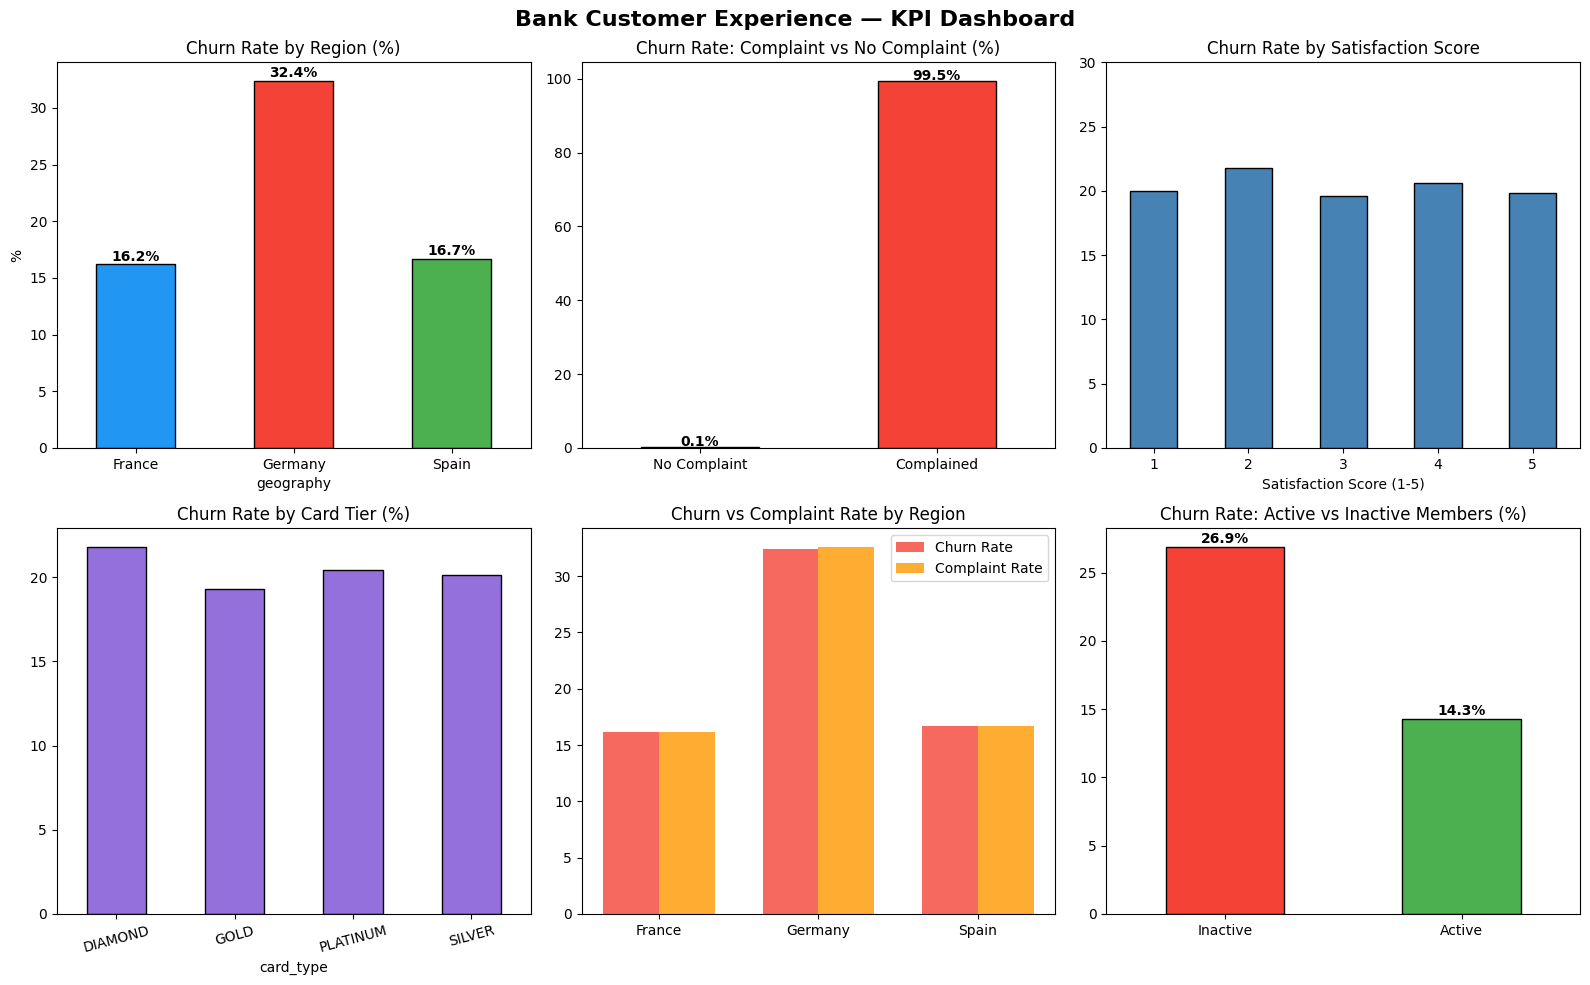

Chart saved!


In [13]:
# ---- All KPI Charts ----
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Bank Customer Experience — KPI Dashboard', fontsize=16, fontweight='bold')

# Chart 1: Churn Rate by Region
regional['churn_rate_pct'].plot(kind='bar', ax=axes[0,0], 
    color=['#2196F3','#F44336','#4CAF50'], edgecolor='black')
axes[0,0].set_title('Churn Rate by Region (%)')
axes[0,0].set_ylabel('%')
axes[0,0].tick_params(axis='x', rotation=0)
for i, v in enumerate(regional['churn_rate_pct']):
    axes[0,0].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

# Chart 2: Complaint vs No Complaint Churn
complaint_impact['churn_rate_pct'].plot(kind='bar', ax=axes[0,1],
    color=['#4CAF50','#F44336'], edgecolor='black')
axes[0,1].set_title('Churn Rate: Complaint vs No Complaint (%)')
axes[0,1].tick_params(axis='x', rotation=0)
for i, v in enumerate(complaint_impact['churn_rate_pct']):
    axes[0,1].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

# Chart 3: Satisfaction Score vs Churn Rate
sat_churn['churn_rate_pct'].plot(kind='bar', ax=axes[0,2],
    color='steelblue', edgecolor='black')
axes[0,2].set_title('Churn Rate by Satisfaction Score')
axes[0,2].set_xlabel('Satisfaction Score (1-5)')
axes[0,2].tick_params(axis='x', rotation=0)
axes[0,2].set_ylim(0, 30)

# Chart 4: Churn Rate by Card Tier
card_kpis['churn_rate_pct'].plot(kind='bar', ax=axes[1,0],
    color='mediumpurple', edgecolor='black')
axes[1,0].set_title('Churn Rate by Card Tier (%)')
axes[1,0].tick_params(axis='x', rotation=15)

# Chart 5: Regional Complaint vs Churn overlay
x = range(len(regional))
width = 0.35
axes[1,1].bar([i - width/2 for i in x], regional['churn_rate_pct'], 
    width, label='Churn Rate', color='#F44336', alpha=0.8)
axes[1,1].bar([i + width/2 for i in x], regional['complaint_rate_pct'], 
    width, label='Complaint Rate', color='#FF9800', alpha=0.8)
axes[1,1].set_title('Churn vs Complaint Rate by Region')
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(regional.index)
axes[1,1].legend()

# Chart 6: Active vs Inactive churn
active_churn = df.groupby('isactivemember')['exited'].mean().mul(100).round(1)
active_churn.index = ['Inactive', 'Active']
active_churn.plot(kind='bar', ax=axes[1,2],
    color=['#F44336','#4CAF50'], edgecolor='black')
axes[1,2].set_title('Churn Rate: Active vs Inactive Members (%)')
axes[1,2].tick_params(axis='x', rotation=0)
for i, v in enumerate(active_churn):
    axes[1,2].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/charts/kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [14]:
# ---- CX Risk Scoring ----
df['cx_risk_score'] = (
    (df['satisfaction_score'].max() - df['satisfaction_score']) * 2 +  # low sat = high risk
    df['complain'] * 3 +                                                 # complaint = big red flag
    (1 - df['isactivemember']) * 1.5 +                                  # inactive = risk
    (df['numofproducts'] >= 3).astype(int) * 1                          # over-sold = risk
)

# Segment into tiers
df['cx_segment'] = pd.cut(
    df['cx_risk_score'],
    bins=[-1, 2, 4, 6, 100],
    labels=['Loyal', 'At Risk', 'High Risk', 'Critical']
)

print(df['cx_segment'].value_counts())
print(f"\nRisk score range: {df['cx_risk_score'].min()} - {df['cx_risk_score'].max()}")

cx_segment
Critical     3757
Loyal        2458
High Risk    1973
At Risk      1812
Name: count, dtype: int64

Risk score range: 0.0 - 13.5


In [15]:
# ---- Validate Segments Against Actual Churn ----
seg_summary = df.groupby('cx_segment', observed=True).agg(
    total_customers=('exited', 'count'),
    actual_churn_rate=('exited', 'mean'),
    complaint_rate=('complain', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_balance=('balance', 'mean'),
    avg_tenure=('tenure', 'mean')
).round(3)

seg_summary['churn_rate_pct'] = (seg_summary['actual_churn_rate'] * 100).round(1)
seg_summary['complaint_rate_pct'] = (seg_summary['complaint_rate'] * 100).round(1)

print(seg_summary[['total_customers', 'churn_rate_pct', 'complaint_rate_pct', 
                    'avg_satisfaction', 'avg_balance', 'avg_tenure']])

            total_customers  churn_rate_pct  complaint_rate_pct  \
cx_segment                                                        
Loyal                  2458             0.0                 0.0   
At Risk                1812             8.5                 8.5   
High Risk              1973            19.7                19.8   
Critical               3757            39.8                39.9   

            avg_satisfaction  avg_balance  avg_tenure  
cx_segment                                             
Loyal                  4.651    72447.650       5.020  
At Risk                3.579    75931.101       5.025  
High Risk              2.885    75423.513       5.101  
Critical               1.738    79953.373       4.956  


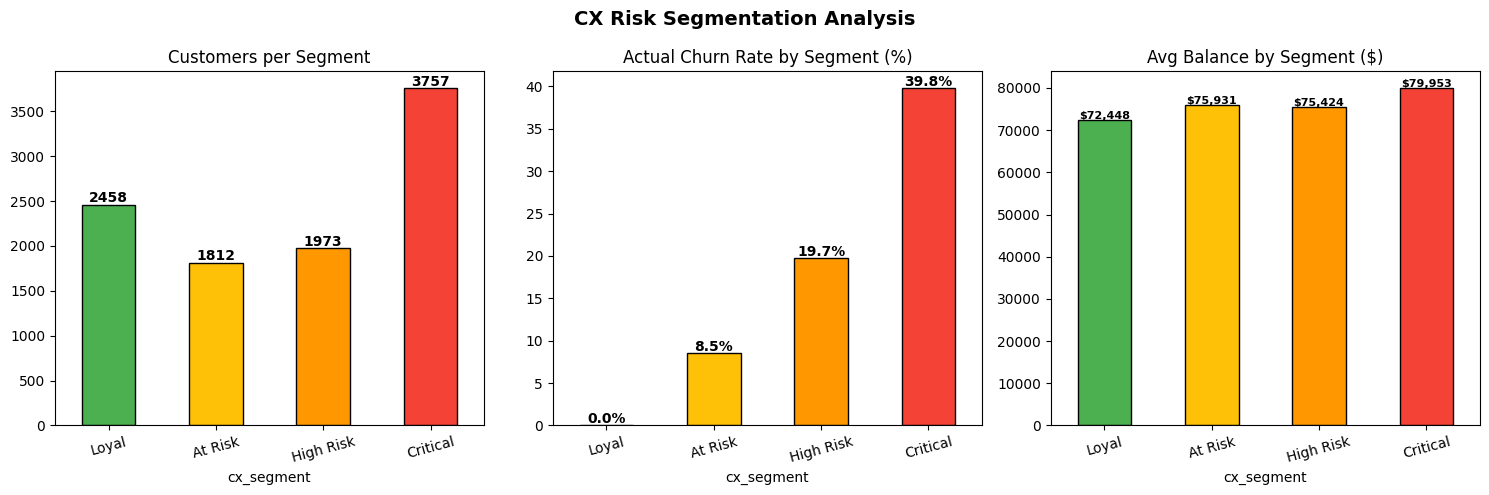

Saved!


In [16]:
# ---- Segment Visualization ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('CX Risk Segmentation Analysis', fontsize=14, fontweight='bold')

colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']

# Chart 1: Customer count per segment
seg_summary['total_customers'].plot(kind='bar', ax=axes[0],
    color=colors, edgecolor='black')
axes[0].set_title('Customers per Segment')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(seg_summary['total_customers']):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Chart 2: Churn rate per segment
seg_summary['churn_rate_pct'].plot(kind='bar', ax=axes[1],
    color=colors, edgecolor='black')
axes[1].set_title('Actual Churn Rate by Segment (%)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(seg_summary['churn_rate_pct']):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

# Chart 3: Avg balance per segment (the premium retention insight)
seg_summary['avg_balance'].plot(kind='bar', ax=axes[2],
    color=colors, edgecolor='black')
axes[2].set_title('Avg Balance by Segment ($)')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(seg_summary['avg_balance']):
    axes[2].text(i, v + 300, f'${v:,.0f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/charts/segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [17]:
# ---- Rebuild cx_segment for this notebook ----
df['cx_risk_score'] = (
    (df['satisfaction_score'].max() - df['satisfaction_score']) * 2 +
    df['complain'] * 3 +
    (1 - df['isactivemember']) * 1.5 +
    (df['numofproducts'] >= 3).astype(int) * 1
)

df['cx_segment'] = pd.cut(
    df['cx_risk_score'],
    bins=[-1, 2, 4, 6, 100],
    labels=['Loyal', 'At Risk', 'High Risk', 'Critical']
)

print(df['cx_segment'].value_counts())

cx_segment
Critical     3757
Loyal        2458
High Risk    1973
At Risk      1812
Name: count, dtype: int64


In [19]:
# ---- Redefine model variables for this notebook ----
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
df['geography_enc'] = le.fit_transform(df['geography'])
df['gender_enc'] = le.fit_transform(df['gender'])
df['card_type_enc'] = le.fit_transform(df['card_type'])

features_clean = [
    'creditscore', 'geography_enc', 'gender_enc', 'age', 'tenure',
    'balance', 'numofproducts', 'hascrcard', 'isactivemember',
    'estimatedsalary', 'satisfaction_score', 'card_type_enc', 'point_earned'
]

X2 = df[features_clean]
y2 = df['exited']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

scaler2 = StandardScaler()
X_train2_s = scaler2.fit_transform(X_train2)
X_test2_s = scaler2.transform(X_test2)

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train2_s, y_train2)
lr2_auc = roc_auc_score(y_test2, lr2.predict_proba(X_test2_s)[:,1])

rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train2, y_train2)
rf2_auc = roc_auc_score(y_test2, rf2.predict_proba(X_test2)[:,1])

print("Models retrained successfully")
print(f"LR AUC: {lr2_auc:.3f} | RF AUC: {rf2_auc:.3f}")

Models retrained successfully
LR AUC: 0.775 | RF AUC: 0.859


In [20]:
# ---- Export to Excel ----
from openpyxl import load_workbook

# Rebuild kpi_summary as dataframe
kpi_df = pd.DataFrame(list({
    'Total Customers': len(df),
    'Churn Rate (%)': round(df['exited'].mean() * 100, 2),
    'Complaint Rate (%)': round(df['complain'].mean() * 100, 2),
    'Avg Satisfaction Score': round(df['satisfaction_score'].mean(), 2),
    'Active Member Rate (%)': round(df['isactivemember'].mean() * 100, 2),
    'Avg Tenure (Years)': round(df['tenure'].mean(), 1),
    'Avg Credit Score': round(df['creditscore'].mean(), 0)
}.items()), columns=['KPI', 'Value'])

# Regional analysis
regional = df.groupby('geography').agg(
    total_customers=('exited', 'count'),
    churn_rate_pct=('exited', 'mean'),
    complaint_rate_pct=('complain', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_balance=('balance', 'mean')
).round(3)
regional['churn_rate_pct'] = (regional['churn_rate_pct'] * 100).round(1)
regional['complaint_rate_pct'] = (regional['complaint_rate_pct'] * 100).round(1)

# Segment summary
seg_summary = df.groupby('cx_segment', observed=True).agg(
    total_customers=('exited', 'count'),
    churn_rate_pct=('exited', 'mean'),
    complaint_rate_pct=('complain', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_balance=('balance', 'mean')
).round(3)
seg_summary['churn_rate_pct'] = (seg_summary['churn_rate_pct'] * 100).round(1)
seg_summary['complaint_rate_pct'] = (seg_summary['complaint_rate_pct'] * 100).round(1)

# Feature importance
feat_importance = pd.DataFrame({
    'feature': features_clean,
    'importance': rf2.feature_importances_
}).sort_values('importance', ascending=False).round(4)

# Model comparison
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'AUC': [round(lr2_auc, 3), round(rf2_auc, 3)],
    'Note': ['Leaky features removed', 'Leaky features removed']
})

# Write to Excel
with pd.ExcelWriter('../outputs/cx_dashboard.xlsx', engine='openpyxl') as writer:
    kpi_df.to_excel(writer, sheet_name='CX Health KPIs', index=False)
    regional.to_excel(writer, sheet_name='Regional Analysis')
    seg_summary.to_excel(writer, sheet_name='CX Segments')
    feat_importance.to_excel(writer, sheet_name='Churn Drivers', index=False)
    model_comparison.to_excel(writer, sheet_name='Model Comparison', index=False)

print("Excel dashboard saved to outputs/cx_dashboard.xlsx")

Excel dashboard saved to outputs/cx_dashboard.xlsx
